<a href="https://colab.research.google.com/github/gaelBZH/NumericalMethods/blob/main/Laboratory4/Laboratory_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory 4
Gaël Kerninon

## Exercise 1

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def f(x):
   return np.sin(4*x)*x

# Defining derivative of function
def g(x):
   return np.sin(4*x) + 4*np.cos(4*x)*x

# Implementing Newton Method with 3 Stopping Criterias
def newton(x0, tolx, tolf, nmax):
   """
   Returns (root, step)
   """
   step = 1

   # Criteria 1: n <= n_max
   while step <= nmax:
      if g(x0) == 0.0:
         raise ZeroDivisionError(f"g({x0=})=0.0 ({step=})")

      x1 = x0 - f(x0)/g(x0)

      # Criteria 2 and 3: TOLX and TOLF
      if abs(x1 - x0) <= tolx or abs(f(x1)) <= tolf:
         return x1, step

      x0 = x1
      step += 1

   # Non convergent after nmax iterations
   return None, nmax


x0 = float(input('Enter Guess: '))
tolx = float(input('TOLX (Error on x): '))
tolf = float(input('TOLF (Error on f(x)): '))
nmax = int(input('Maximum Step: '))
root, iterations = newton(x0, tolx, tolf, nmax)
if root is not None:
   print(f"Root: {root}, Iterations: {iterations}")
else:
   print("Did not converge.")

Enter Guess: 5
TOLX (Error on x): 0.000001
TOLF (Error on f(x)): 0.000001
Maximum Step: 50
Root: 4.712388980385529, Iterations: 5


## Exercise 2

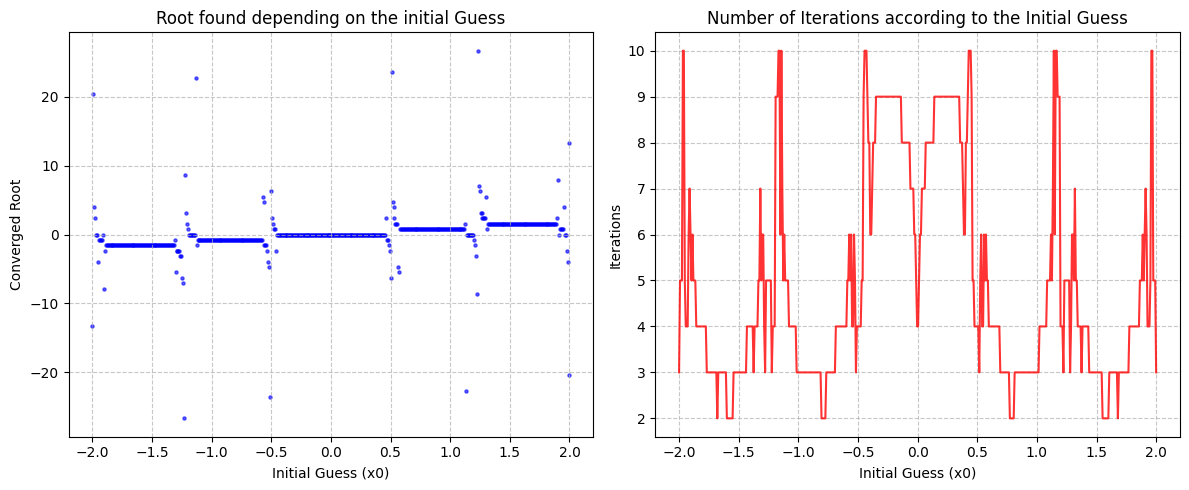

In [5]:
TOLX = 1e-6
TOLF = 1e-6
NMAX = 50

roots_found = []
iterations_needed = []
valid_guesses = []

# Loop with different initial points
for x0 in np.linspace(-2.0, 2.0, 500):
    root, steps = newton(x0, TOLX, TOLF, NMAX)
    if root is not None:
        roots_found.append(root)
        iterations_needed.append(steps)
        valid_guesses.append(x0)

# Results
plt.figure(figsize=(12, 5))
colors = ["blue", "red"]

# Graph 1
plt.subplot(1, 2, 1)
plt.scatter(valid_guesses, roots_found, s=5, c=colors[0], alpha=0.6)
plt.title("Root found depending on the initial Guess")
plt.xlabel("Initial Guess (x0)")
plt.ylabel("Converged Root")
plt.grid(True, linestyle='--', alpha=0.7)

# Graph 2
plt.subplot(1, 2, 2)
plt.plot(valid_guesses, iterations_needed, c=colors[1], alpha=0.8)
plt.title("Number of Iterations according to the Initial Guess")
plt.xlabel("Initial Guess (x0)")
plt.ylabel("Iterations")
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()